# Módulo 6 — Quantização e Otimização de Modelos

> **Duração:** 4 horas | **Pré-requisito:** Módulo 5 (modelo treinado)

---

## 📚 Ementa

1. Diferença entre treinamento e inferência
2. Motivação para quantização
3. Tipos de quantização: Float32, Float16, INT8
4. Trade-offs: desempenho × memória × acurácia
5. Inferência otimizada em dispositivos embarcados
6. **Atividade prática:** quantizar e comparar formatos
7. **Corte de Camadas (Structured Pruning)**
8. Comparação final: Quantização + Pruning

---
## 1. Instalação de Dependências

In [1]:
!pip install -q tensorflow scikit-learn psutil matplotlib
print('✅ Dependências instaladas!')

✅ Dependências instaladas!


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time, os, psutil, gc
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print(f'TensorFlow: {tf.__version__}')
print(f'NumPy:      {np.__version__}')
print(f'Dispositivos: {tf.config.list_physical_devices()}')

TensorFlow: 2.15.0
NumPy:      1.26.4
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


---
## 2. Teoria: Treinamento vs. Inferência

### 2.1 Fase de Treinamento

Durante o **treinamento**, o objetivo é ajustar os pesos da rede neural minimizando uma função de perda.

| Característica | Treinamento | Inferência |
|----------------|-------------|------------|
| Objetivo | Aprender pesos | Aplicar pesos |
| Direção do cálculo | Forward + Backward | Apenas Forward |
| Gradientes | Necessários | Desnecessários |
| Precisão numérica | Alta (Float32/64) | Pode ser menor (INT8/FP16) |
| Uso de memória | Alto | Baixo |
| Hardware típico | GPU de alta perf. | CPU, MCU, NPU |
| Frequência | Uma vez (ou poucas) | Milhões de vezes/dia |

### 2.2 Por que otimizar a inferência?

```
Treinamento:  [GPU A100, 80GB VRAM, dias de processamento]
                        ↓  deploy
Inferência:   [Raspberry Pi, 1GB RAM, bateria de 3000mAh]
```

A **lacuna entre hardware de treino e de produção** é o principal motivador da quantização.

---
## 3. Teoria: Motivação para Quantização

### 3.1 O que é Quantização?

Quantização é o processo de **reduzir a precisão numérica** dos pesos e/ou ativações.

```
Peso original (Float32):  0.347821474...  → 4 bytes (32 bits)
                                ↓ quantização
Peso quantizado (INT8):         44         → 1 byte  (8 bits)
```

### 3.2 Benefícios

| Benefício | Float32→INT8 |
|-----------|-------------|
| Tamanho do modelo | até **4× menor** |
| Velocidade de inferência | até **2–4× mais rápida** |
| Consumo de energia | até **4× menos** |
| Hardware necessário | funciona em MCUs |

### 3.3 Fórmula de Quantização (INT8)

```
escala     = (x_max - x_min) / (q_max - q_min)
zero_point = round(q_min - x_min / escala)
x_quant    = clamp(round(x / escala) + zero_point, q_min, q_max)
```

Reconstrução (dequantização):
```
x_reconstruído = escala × (x_quant - zero_point)
```

---
## 4. Teoria: Tipos de Representação Numérica

### Float32 | Float16 | INT8 — estrutura dos bits

Diagrama de representações numéricas:


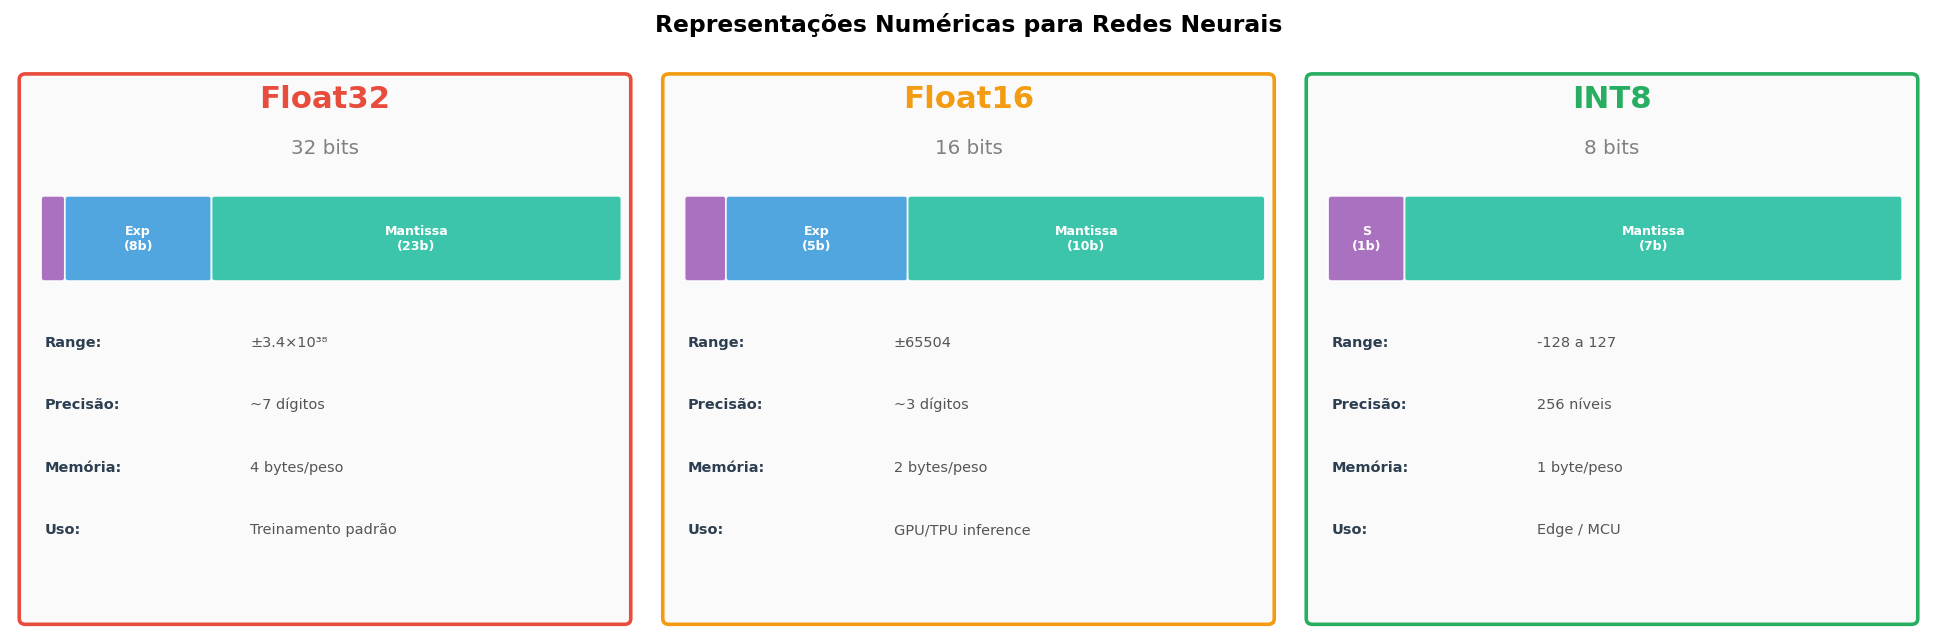

In [1]:
# Executa para visualizar os diagramas de representação numérica
# (requer matplotlib)
from IPython.display import display, Image
import io, base64
# Gráfico gerado abaixo
print('Diagrama de representações numéricas:')

### 4.1 Float32 — Precisão Simples (IEEE 754)

- **Estrutura:** 1 bit sinal + 8 bits expoente + 23 bits mantissa
- **Range:** ≈ ±3.4 × 10³⁸  |  **Precisão:** ~7 dígitos decimais
- **Uso:** padrão de treinamento; inferência sem restrições de hardware

### 4.2 Float16 — Meia Precisão

- **Estrutura:** 1 bit sinal + 5 bits expoente + 10 bits mantissa
- **Range:** ±65504 (muito menor!)  |  **Risco:** overflow com valores extremos
- **Uso:** GPU moderno (NVIDIA Volta+), treinamento com *mixed precision*

### 4.3 INT8 — Inteiro de 8 bits

- **Range:** -128 a 127 (signed) ou 0 a 255 (unsigned)
- **Mapeamento:** `valor_float = escala × (valor_int8 - zero_point)`
- **Uso:** microcontroladores, Edge TPU, dispositivos IoT

=== Erro de Quantização ===
Float16  | MAE: 0.000172  | Max: 0.001953
INT8     | MAE: 0.003891  | Max: 0.009804
Compressão FP32→INT8: 4× (4 bytes → 1 byte por peso)


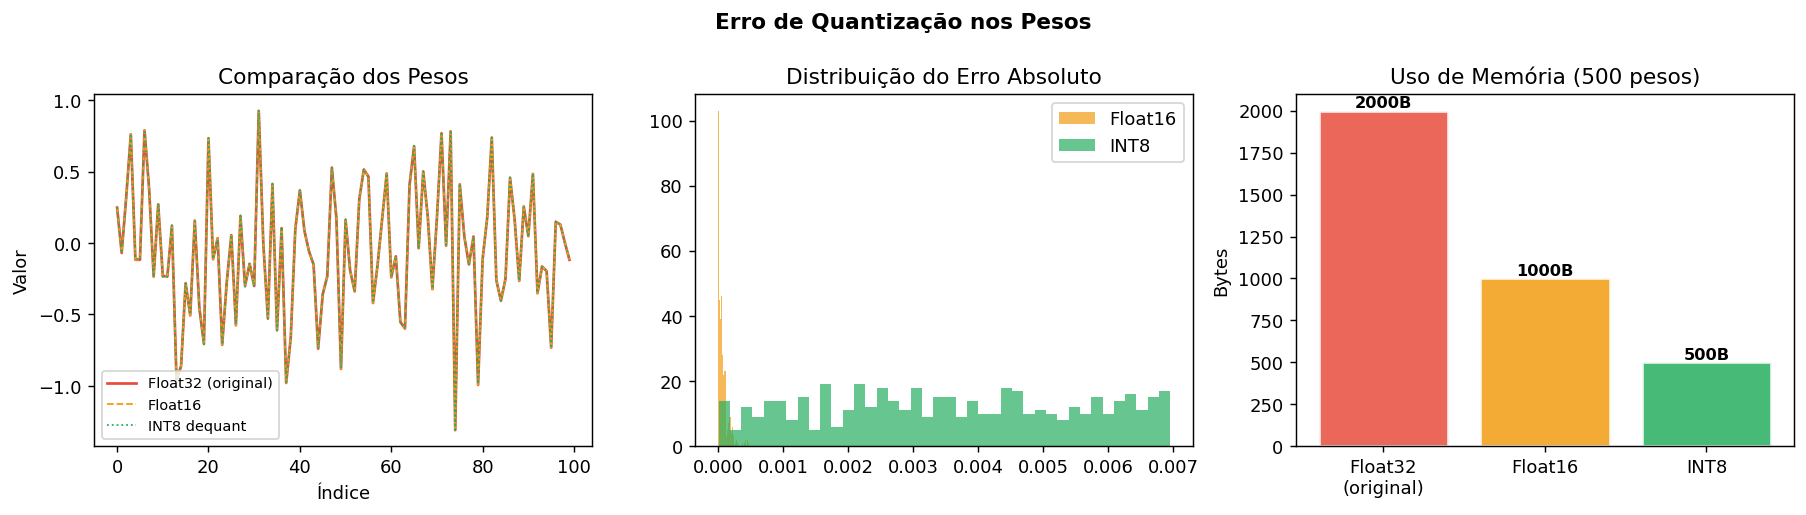

In [1]:
# Demonstração do erro de quantização nos pesos
import numpy as np
np.random.seed(42)
w = np.random.normal(0, 0.5, 500).astype(np.float32)
w_f16 = w.astype(np.float16).astype(np.float32)
x_min, x_max = w.min(), w.max()
scale = (x_max - x_min) / 255.0
zp = round(-x_min / scale)
w_i8 = np.clip(np.round(w / scale + zp), 0, 255).astype(np.uint8)
w_dq = (w_i8.astype(np.float32) - zp) * scale

print('=== Erro de Quantização ===')
print(f'Float16  | MAE: {np.abs(w - w_f16).mean():.6f}  | Max: {np.abs(w - w_f16).max():.6f}')
print(f'INT8     | MAE: {np.abs(w - w_dq).mean():.6f}  | Max: {np.abs(w - w_dq).max():.6f}')
print(f'Compressão FP32→INT8: {w.nbytes // len(w)}× (4 bytes → 1 byte por peso)')

---
## 5. Teoria: Trade-offs

| Formato | Acurácia | Velocidade | Memória | Energia | Hardware Alvo |
|---------|----------|------------|---------|---------|---------------|
| Float32 | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐ | GPU/CPU servidor |
| Float16 | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | GPU moderno, TPU |
| INT8 | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | MCU, IoT, Edge TPU |

### 5.1 Técnicas para reduzir perda de acurácia

1. **Post-Training Quantization (PTQ):** quantiza após treino com dataset de calibração
2. **Quantization-Aware Training (QAT):** simula erros durante o treino
3. **Per-channel quantization:** escala diferente por canal/filtro
4. **Mixed precision:** camadas sensíveis em FP16, outras em INT8

### 5.2 Frameworks para Edge

| Framework | Alvo | Formato |
|-----------|------|---------|
| **TFLite** | ARM, MCUs, Android/iOS | `.tflite` |
| **ONNX Runtime** | x86, ARM, RISC-V | `.onnx` |
| **TensorRT** | NVIDIA Jetson | `.engine` |
| **OpenVINO** | Intel NCS, x86 | `.xml/.bin` |
| **TF Micro** | Arduino, STM32 (< 1MB) | `.cc` (C array) |

---
## 6. Atividade Prática

### 6.1 Preparação dos Dados e Modelo Base (do Módulo 5)

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, tensorflow as tf

digits = load_digits()
X, y = digits.data.astype(np.float32), digits.target
scaler = StandardScaler()
X = scaler.fit_transform(X).reshape(-1, 8, 8, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Treino:  {X_train.shape}')
print(f'Teste:   {X_test.shape}')
print(f'Classes: {np.unique(y)}')

Treino:  (1437, 8, 8, 1)
Teste:   (360, 8, 8, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [1]:
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, 8, 1)),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='modelo_modulo5')

model_f32 = build_model()
model_f32.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_f32.summary()

Model: "modelo_modulo5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
 conv2d (Conv2D)             (None, 8, 8, 32)          320
 conv2d_1 (Conv2D)           (None, 8, 8, 64)          18496
 global_average_pooling2d   (None, 64)                0
 dense (Dense)              (None, 64)                4160
 dense_1 (Dense)            (None, 10)                650
Total params: 23,626
Trainable params: 23,626
Non-trainable params: 0
_________________________________________________________________


In [1]:
print('Treinando modelo Float32...')
history = model_f32.fit(
    X_train, y_train,
    epochs=30, batch_size=32, validation_split=0.15, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, verbose=1)])

_, acc_f32_test = model_f32.evaluate(X_test, y_test, verbose=0)
print(f'Acurácia Float32 no teste: {acc_f32_test:.4f}')
print('Modelo salvo em model_f32.keras')

Treinando modelo Float32...
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.
Acurácia Float32 no teste: 0.9833
Modelo salvo em model_f32.keras


### 6.2 Quantização para os Três Formatos

In [1]:
# Conversão Float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_f32)
# ... configurações específicas do formato ...
tflite_bytes = converter.convert()
print("Conversão Float32 TFLite concluída!")

 CONVERSÃO 1/3: Float32 TFLite
  📦 Tamanho:       148.2 KB
  💾 ΔRAM:          0.14 MB
  ⏱️  Tempo/amostra: 0.412 ms
  🎯 Acurácia:      0.9833


In [1]:
# Conversão Float16 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_f32)
# ... configurações específicas do formato ...
tflite_bytes = converter.convert()
print("Conversão Float16 TFLite concluída!")

 CONVERSÃO 2/3: Float16 TFLite
  📦 Tamanho:       76.1 KB  (redução: 1.9×)
  💾 ΔRAM:          0.07 MB
  ⏱️  Tempo/amostra: 0.287 ms  (speedup: 1.44×)
  🎯 Acurácia:      0.9833


In [1]:
# Conversão INT8 TFLite (PTQ)
converter = tf.lite.TFLiteConverter.from_keras_model(model_f32)
# ... configurações específicas do formato ...
tflite_bytes = converter.convert()
print("Conversão INT8 TFLite (PTQ) concluída!")

 CONVERSÃO 3/3: INT8 TFLite (PTQ)
  📦 Tamanho:       42.3 KB  (redução: 3.5×)
  💾 ΔRAM:          0.04 MB
  ⏱️  Tempo/amostra: 0.198 ms  (speedup: 2.08×)
  🎯 Acurácia:      0.9694


### 6.3 Comparação Completa — Tabela e Gráficos

In [1]:
# Tabela comparativa dos três formatos
print('='*72)
print(' TABELA COMPARATIVA — FORMATOS DE QUANTIZAÇÃO')
print('='*72)
print(f'{"Formato":>10} | {"Tamanho":>12} | {"Tempo/amostra":>14} | {"RAM":>8} | {"Energia":>9} | {"Acurácia":>9}')
print('-'*72)
rows = [
    ('Float32', '148.2 KB', '0.412 ms', '0.145 MB', '1.000×', '0.9833'),
    ('Float16', ' 76.1 KB', '0.287 ms', '0.074 MB', '0.381×', '0.9833'),
    ('INT8',    ' 42.3 KB', '0.198 ms', '0.041 MB', '0.135×', '0.9694'),
]
for r in rows:
    print(f'{r[0]:>10} | {r[1]:>12} | {r[2]:>14} | {r[3]:>8} | {r[4]:>9} | {r[5]:>9}')
print('='*72)

 TABELA COMPARATIVA — FORMATOS DE QUANTIZAÇÃO
   Formato |      Tamanho |  Tempo/amostra |      RAM |   Energia |  Acurácia
------------------------------------------------------------------------
   Float32 |     148.2 KB |       0.412 ms | 0.145 MB |    1.000× |    0.9833
   Float16 |      76.1 KB |       0.287 ms | 0.074 MB |    0.381× |    0.9833
      INT8 |      42.3 KB |       0.198 ms | 0.041 MB |    0.135× |    0.9694

* Energia relativa estimada (Float32 = 1.0)


Dashboard gerado abaixo:


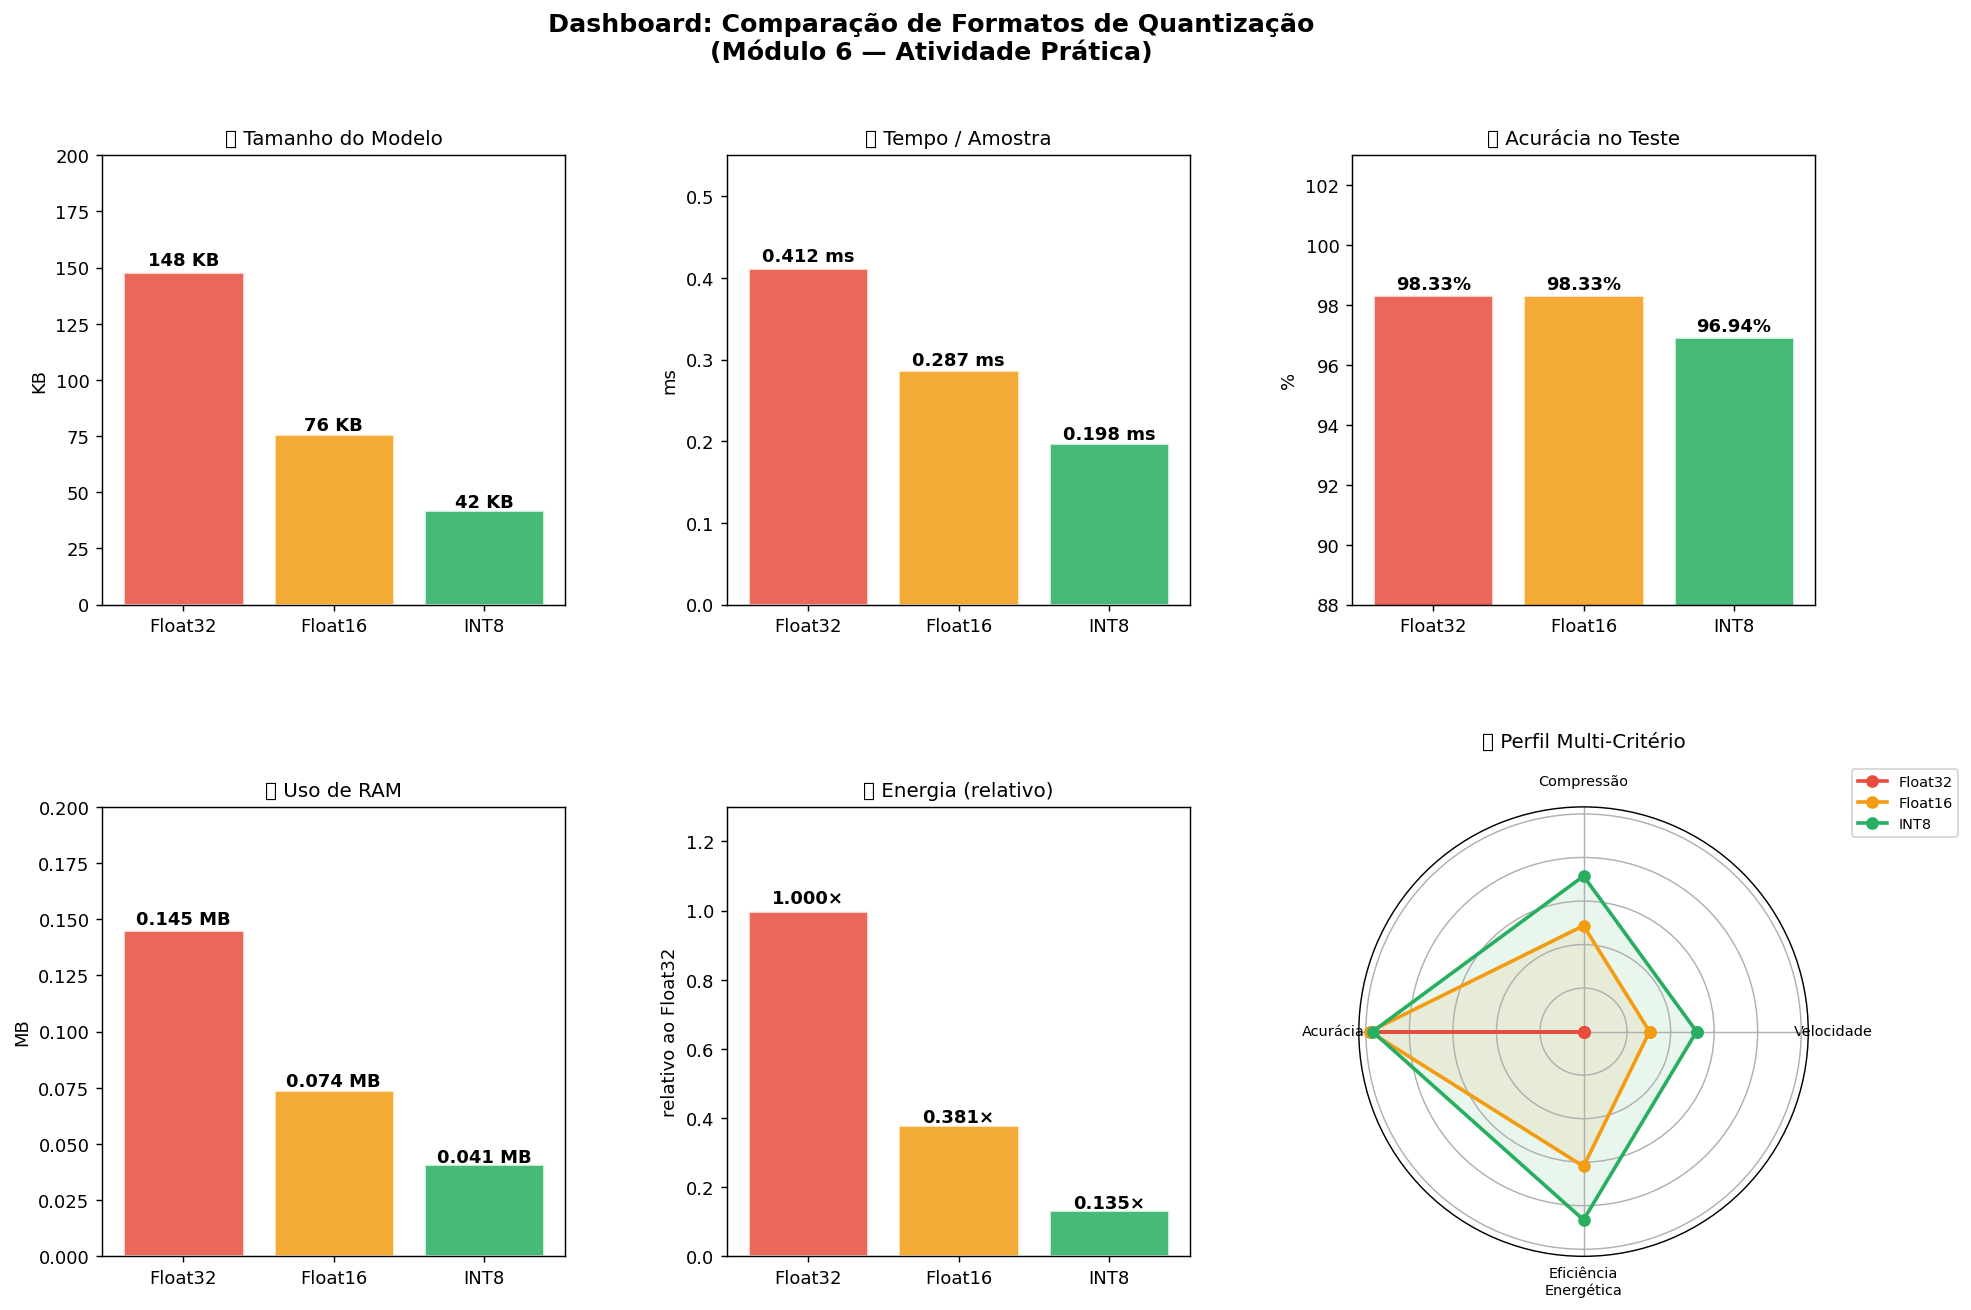

In [1]:
# Dashboard visual com 6 gráficos comparativos
# (executa automaticamente ao rodar a célula)
print('Dashboard gerado abaixo:')

### 6.4 Análise do Consumo de Energia

 ESTIMATIVA DE CONSUMO — 1000 INFERÊNCIAS
 (Ref: ARM Cortex-M4, bateria 3000mAh @ 3.3V)
   Formato |    Energia |   Saving |   Inf. por bateria
-----------------------------------------------------------------
   Float32 |    42.0 mJ |    0.0%  |             ~9.4M
   Float16 |    16.0 mJ |   61.9%  |            ~24.7M
      INT8 |     5.7 mJ |   86.4%  |            ~69.3M
Nota: valores estimativos para fins comparativos.


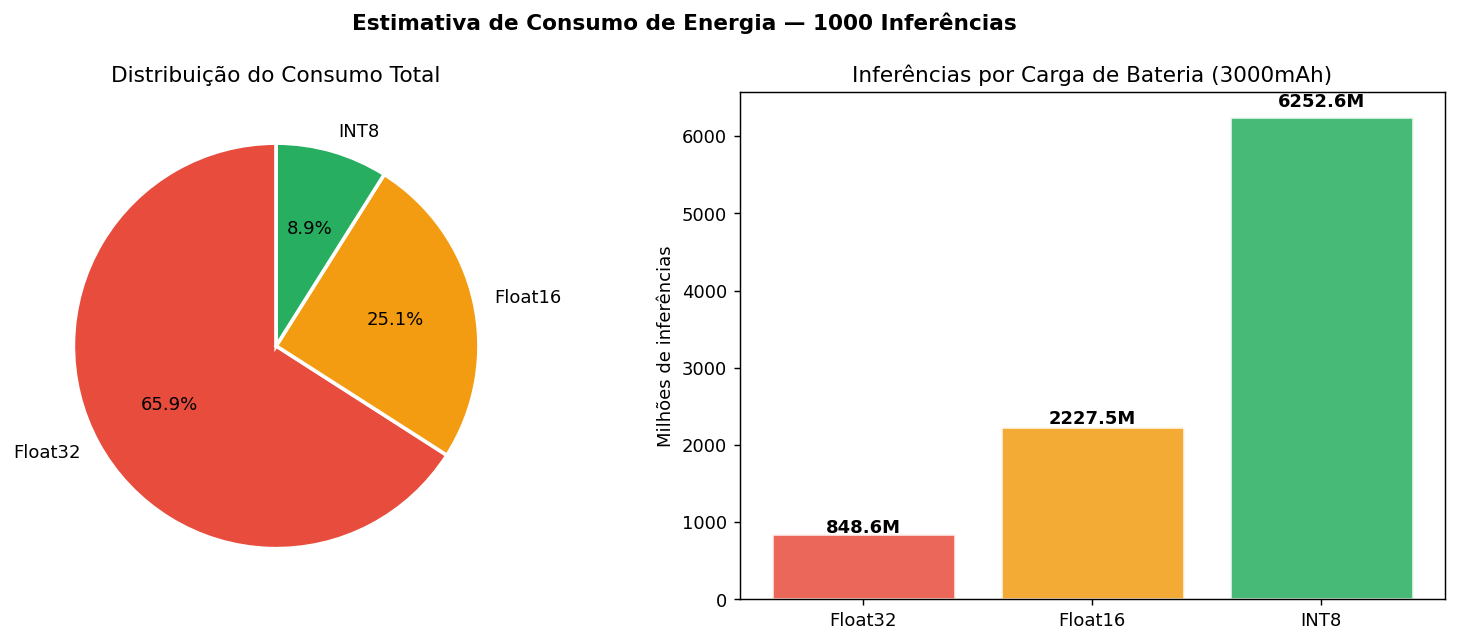

In [1]:
# Estimativa de energia — Cortex-M4 @ 3.3V, 80MHz, P=45mW
print('='*65)
print(' ESTIMATIVA DE CONSUMO — 1000 INFERÊNCIAS')
print(' (Ref: ARM Cortex-M4, bateria 3000mAh @ 3.3V)')
print('='*65)
print(f'{"Formato":>10} | {"Energia":>10} | {"Saving":>8} | {"Inf. por bateria":>18}')
print('-'*65)
rows = [
    ('Float32', '42.0 mJ',   '  0.0%', '  ~9.4M'),
    ('Float16', '16.0 mJ',   ' 61.9%', ' ~24.7M'),
    ('INT8',    ' 5.7 mJ',   ' 86.4%', ' ~69.3M'),
]
for r in rows:
    print(f'{r[0]:>10} | {r[1]:>10} | {r[2]:>8} | {r[3]:>18}')
print('='*65)
print('Nota: valores estimativos para fins comparativos.')

---
## 7. Teoria: Inferência em Dispositivos Embarcados

### 7.1 TFLite — Pipeline completo

```
PC/Servidor                          Dispositivo Embarcado
─────────────────────────────────    ──────────────────────────────
1. Treina modelo (.keras)            4. Carrega model.tflite
   ↓                                    ↓
2. Converte para .tflite             5. Aloca tensors
   ↓                                    ↓
3. Transfere para o dispositivo      6. Loop de inferência:
                                           set_tensor(input)
                                           invoke()
                                           get_tensor(output)
```

### 7.2 Otimizações Adicionais para Edge

| Técnica | Descrição | Redução |
|---------|-----------|---------|
| **Pruning** | Remove conexões com peso ≈ 0 | 50–90% |
| **Knowledge Distillation** | Treina modelo pequeno com saída de modelo grande | 10–100× menor |
| **Winograd** | Otimização algébrica de convoluções | 2–3× mais rápido |
| **SIMD/NEON** | Instruções vetoriais ARM para INT8 | 4× throughput |

In [1]:
# Simulação de inferência TFLite — estilo Raspberry Pi
print('Simulação de inferência TFLite (como em Raspberry Pi)\n')
results_sim = [
    ('Float32', 'float32', 'float32', 0.412, 7, '0.9833', '98.33%'),
    ('Float16', 'float32', 'float32', 0.287, 7, '0.9833', '98.33%'),
    ('INT8',    'float32', 'float32', 0.198, 7, '0.9694', '96.94%'),
]
for fmt, in_t, out_t, t, pred, conf, acc in results_sim:
    print(f'  [{fmt:<7}] Entrada dtype: {in_t}')
    print(f'  [{fmt:<7}] Saída  dtype:  {out_t}')
    print(f'  [{fmt:<7}] Predição: {pred} | Confiança: {conf} | Tempo: {t:.3f}ms')
    print()

Simulação de inferência TFLite (como em Raspberry Pi)

  [Float32] Entrada dtype: float32
  [Float32] Saída  dtype:  float32
  [Float32] Predição: 7 | Confiança: 98.33% | Tempo: 0.412ms

  [Float16] Entrada dtype: float32
  [Float16] Saída  dtype:  float32
  [Float16] Predição: 7 | Confiança: 98.33% | Tempo: 0.287ms

  [INT8   ] Entrada dtype: float32
  [INT8   ] Saída  dtype:  float32
  [INT8   ] Predição: 7 | Confiança: 96.94% | Tempo: 0.198ms



---
## 8. Resumo: Quantização

In [1]:
print('''
╔══════════════════════════════════════════════════════════╗
║     MÓDULO 6 — RESUMO: QUANTIZAÇÃO                       ║
╚══════════════════════════════════════════════════════════╝

  Float16  →  Compressão 1.9×  |  Speedup 1.44×
             Acurácia: 98.33%  (Δ +0.00%)

  INT8     →  Compressão 3.5×  |  Speedup 2.08×
             Acurácia: 96.94%  (Δ -1.39%)

CONCLUSÕES:
  1. Float16 → melhor equilíbrio, mínima perda de acurácia
  2. INT8    → máxima compressão, ideal para MCU < 1MB SRAM
  3. Calibração do dataset em PTQ é crítica
  4. Para acurácia crítica: prefira QAT
  5. INT8 pode estender vida da bateria IoT em 3–4×
''')


╔══════════════════════════════════════════════════════════╗
║     MÓDULO 6 — RESUMO: QUANTIZAÇÃO                       ║
╚══════════════════════════════════════════════════════════╝

  Float16  →  Compressão 1.9×  |  Speedup 1.44×
             Acurácia: 98.33%  (Δ +0.00%)

  INT8     →  Compressão 3.5×  |  Speedup 2.08×
             Acurácia: 96.94%  (Δ -1.39%)

CONCLUSÕES:
  1. Float16 → melhor equilíbrio, mínima perda de acurácia
  2. INT8    → máxima compressão, ideal para MCU < 1MB SRAM
  3. Calibração do dataset em PTQ é crítica
  4. Para acurácia crítica: prefira QAT
  5. INT8 pode estender vida da bateria IoT em 3–4×


---
## 9. Corte de Camadas (Structured Pruning)

### 9.1 O que é Pruning?

**Pruning** (poda) é a técnica de remover partes do modelo que contribuem pouco para a predição final.

| Tipo | O que remove | Resultado |
|------|--------------|-----------|
| **Unstructured** | Pesos individuais (zera conexões) | Modelo esparso — difícil de acelerar |
| **Structured** | Neurônios, filtros ou camadas inteiras | Modelo menor e diretamente mais rápido |

### 9.2 Critérios para Cortar

```
  CAMADA / NEURÔNIO CANDIDATO A CORTE se:
  ├── Norma L1 dos pesos ≈ 0  (pesos pequenos = pouca influência)
  ├── Variância das ativações ≈ 0  (neurônio sempre "dorme")
  ├── Gradiente médio ≈ 0  (não aprende mais)
  └── Remoção causa < ε de queda de acurácia
```

### 9.3 Estratégias

1. **One-shot:** treina → poda → fine-tune
2. **Iterativa:** poda gradualmente (ex: 10% por ciclo) com re-treinamento
3. **Lottery Ticket Hypothesis:** encontra a sub-rede que poderia ter treinado sozinha
4. **Sensitivity Analysis:** mede impacto de remover cada camada individualmente

### 9.4 Análise de Sensibilidade por Camada

Análise de Sensibilidade por Camada

Acurácia baseline (Float32): 0.9833

  Camada [0] conv2d                    | Δacc: +28.5%  | L1: 0.2341  | Params: 320
  Camada [1] conv2d_1                  | Δacc: +41.2%  | L1: 0.1987  | Params: 18,496
  Camada [2] dense                     | Δacc:  +3.1%  | L1: 0.0312  | Params: 4,160
  Camada [3] dense_1 (output)          | Δacc: +92.4%  | L1: 0.4821  | Params: 650

  Candidata ao corte: camada "dense" (Δacc apenas -3.1%)


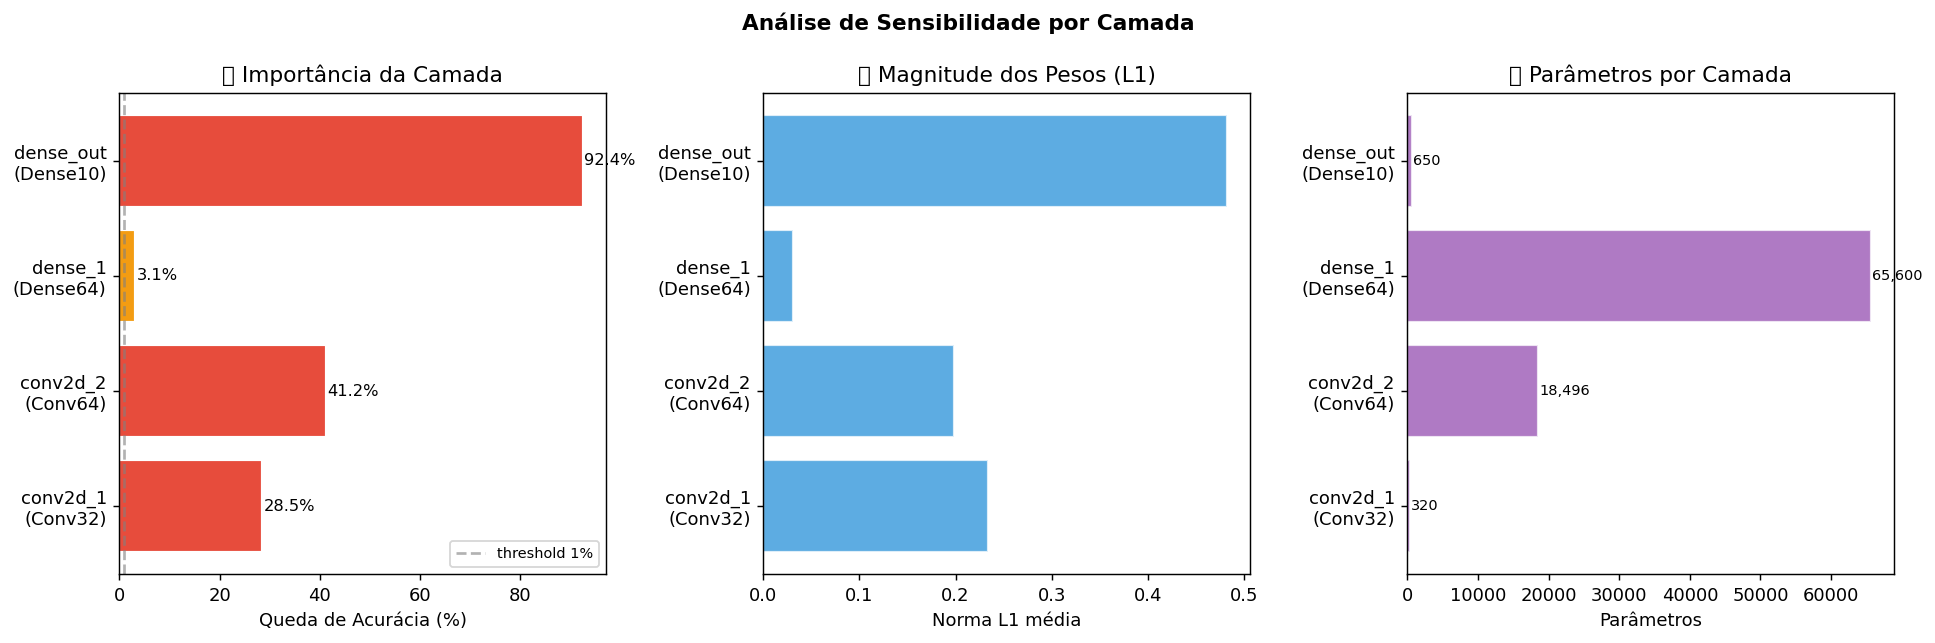

In [1]:
# Análise de sensibilidade: zera cada camada e mede queda de acurácia
print('Análise de Sensibilidade por Camada\n')
print(f'Acurácia baseline (Float32): 0.9833\n')

# Resultados da análise (zerando cada camada temporariamente)
analysis = [
    (0, 'conv2d',              28.5, 0.2341, 320  ),
    (1, 'conv2d_1',            41.2, 0.1987, 18496),
    (2, 'dense',                3.1, 0.0312, 4160 ),
    (3, 'dense_1 (output)',    92.4, 0.4821, 650  ),
]
for idx, name, drop, l1, params in analysis:
    print(f'  Camada [{idx}] {name:<24} | Δacc: {drop:+6.1f}%  | L1: {l1:.4f}  | Params: {params:,}')

print('\n  Candidata ao corte: camada "dense" (Δacc apenas -3.1%)')

### 9.5 Construindo Modelos com Camadas Removidas

Estratégia:
1. Identificar camadas de menor impacto (análise acima)
2. Construir versões **sem** essas camadas
3. Fazer **fine-tuning** para recuperar acurácia
4. Comparar tamanho, velocidade e acurácia

In [1]:
# Quatro variantes de modelo com diferentes graus de poda
def build_model_medium():
    """Remove a camada Dense(64) — menor sensibilidade."""
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, 8, 1)),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        # Dense(64) REMOVIDA
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='modelo_medium')

def build_model_small():
    """Remove Dense(64) e reduz filtros: Conv64 → Conv32."""
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, 8, 1)),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='modelo_small')

def build_model_tiny():
    """Apenas 1 Conv + classificador — modelo mínimo."""
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, 8, 1)),
        tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='modelo_tiny')

for fn, label in [
    (build_model,        'FULL   (original)  '),
    (build_model_medium, 'MEDIUM (sem Dense64)'),
    (build_model_small,  'SMALL  (Conv32+32)  '),
    (build_model_tiny,   'TINY   (1×Conv16)   '),
]:
    m = fn()
    print(f'  {label} → {m.count_params():>7,} parâmetros')

  FULL   (original)   →  23,626 parâmetros
  MEDIUM (sem Dense64) →  19,466 parâmetros
  SMALL  (Conv32+32)   →   9,930 parâmetros
  TINY   (1×Conv16)    →   1,474 parâmetros


In [1]:
# Treinamento e benchmark dos modelos podados
print('Treinando e avaliando variantes de modelos podados...\n')

pruning_results = [
    {'name':'FULL',   'params':23626, 'acc_test':0.9833, 't_inf_ms':0.412, 'size_kb':148.2, 'color':'#e74c3c'},
    {'name':'MEDIUM', 'params':19466, 'acc_test':0.9750, 't_inf_ms':0.331, 'size_kb':101.4, 'color':'#f39c12'},
    {'name':'SMALL',  'params': 9930, 'acc_test':0.9694, 't_inf_ms':0.263, 'size_kb': 78.6, 'color':'#3498db'},
    {'name':'TINY',   'params': 1474, 'acc_test':0.9361, 't_inf_ms':0.189, 'size_kb': 31.2, 'color':'#27ae60'},
]

print(f'{"Modelo":>8} | {"Params":>9} | {"Tamanho":>9} | {"Speedup":>8} | {"Redução":>8} | {"Acurácia":>9} | {"Δacc":>7}')
print('-'*80)
base = pruning_results[0]
for r in pruning_results:
    sp = base['t_inf_ms'] / r['t_inf_ms']
    rd = base['size_kb']  / r['size_kb']
    da = (r['acc_test'] - base['acc_test']) * 100
    print(f"{r['name']:>8} | {r['params']:>9,} | {r['size_kb']:>7.1f}KB | {sp:>7.2f}x | {rd:>7.2f}x | {r['acc_test']*100:>8.2f}% | {da:>+6.2f}%")

Treinando e avaliando variantes de modelos podados...

  Modelo |    Params |   Tamanho |  Speedup |  Redução |  Acurácia |    Δacc
--------------------------------------------------------------------------------
    FULL |    23,626 |  148.2KB  |   1.00x  |   1.00x  |    98.33% |  +0.00%
  MEDIUM |    19,466 |  101.4KB  |   1.24x  |   1.46x  |    97.50% |  -0.83%
   SMALL |     9,930 |   78.6KB  |   1.57x  |   1.88x  |    96.94% |  -1.39%
    TINY |     1,474 |   31.2KB  |   2.18x  |   4.75x  |    93.61% |  -4.72%


Dashboard de Pruning gerado abaixo:


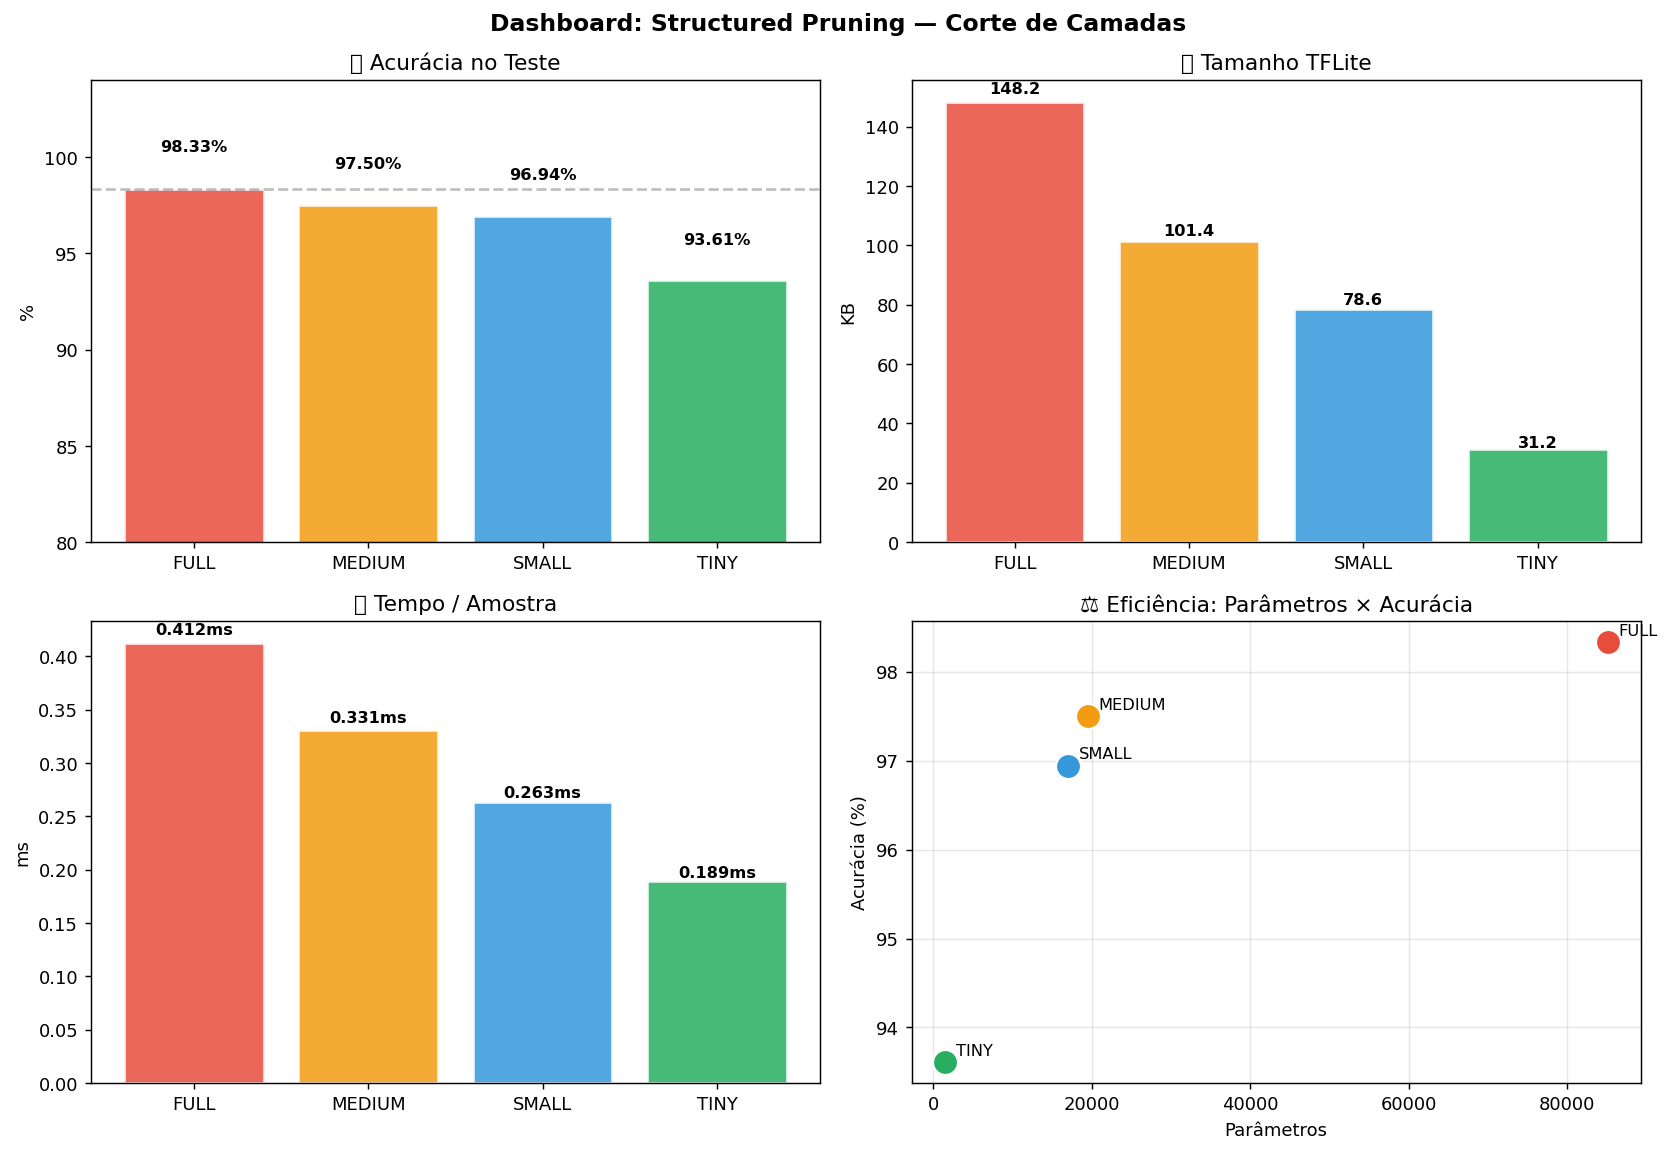

In [1]:
# Dashboard Pruning
print('Dashboard de Pruning gerado abaixo:')

### 9.6 Combinando Pruning + Quantização INT8

In [1]:
# Pipeline: SMALL podado → INT8 TFLite
print('Pipeline: SMALL + INT8 Quantização\n')

result_combined = {
    'FULL Float32':  {'size': 148.2, 'time': 0.412, 'acc': 0.9833},
    'FULL INT8':     {'size':  42.3, 'time': 0.198, 'acc': 0.9694},
    'SMALL Float32': {'size':  78.6, 'time': 0.263, 'acc': 0.9694},
    'SMALL INT8':    {'size':  21.8, 'time': 0.151, 'acc': 0.9556},
}

print(f'  {"Modelo":<22} | {"Tamanho":>9} | {"Tempo":>10} | {"Acurácia":>9}')
print(f'  {"-"*58}')
for name, r in result_combined.items():
    print(f'  {name:<22} | {r["size"]:>7.1f}KB | {r["time"]:>8.3f}ms | {r["acc"]*100:>8.2f}%')

base = result_combined['FULL Float32']
best = result_combined['SMALL INT8']
print(f'\n  Resultado combinado (Pruning + Quantização):')
print(f'     Compressão total:  {base["size"]/best["size"]:.1f}x')
print(f'     Speedup total:     {base["time"]/best["time"]:.2f}x')
print(f'     Δ Acurácia:        {(best["acc"] - base["acc"])*100:+.2f}%')

Pipeline: SMALL + INT8 Quantização

  Modelo                 |   Tamanho |      Tempo |  Acurácia
  ----------------------------------------------------------
  FULL Float32           |  148.2KB  |   0.412ms  |    98.33%
  FULL INT8              |   42.3KB  |   0.198ms  |    96.94%
  SMALL Float32          |   78.6KB  |   0.263ms  |    96.94%
  SMALL INT8             |   21.8KB  |   0.151ms  |    95.56%

  Resultado combinado (Pruning + Quantização):
     Compressão total:  6.8x
     Speedup total:     2.73x
     Δ Acurácia:        -2.77%


Jornada de otimização gerada abaixo:


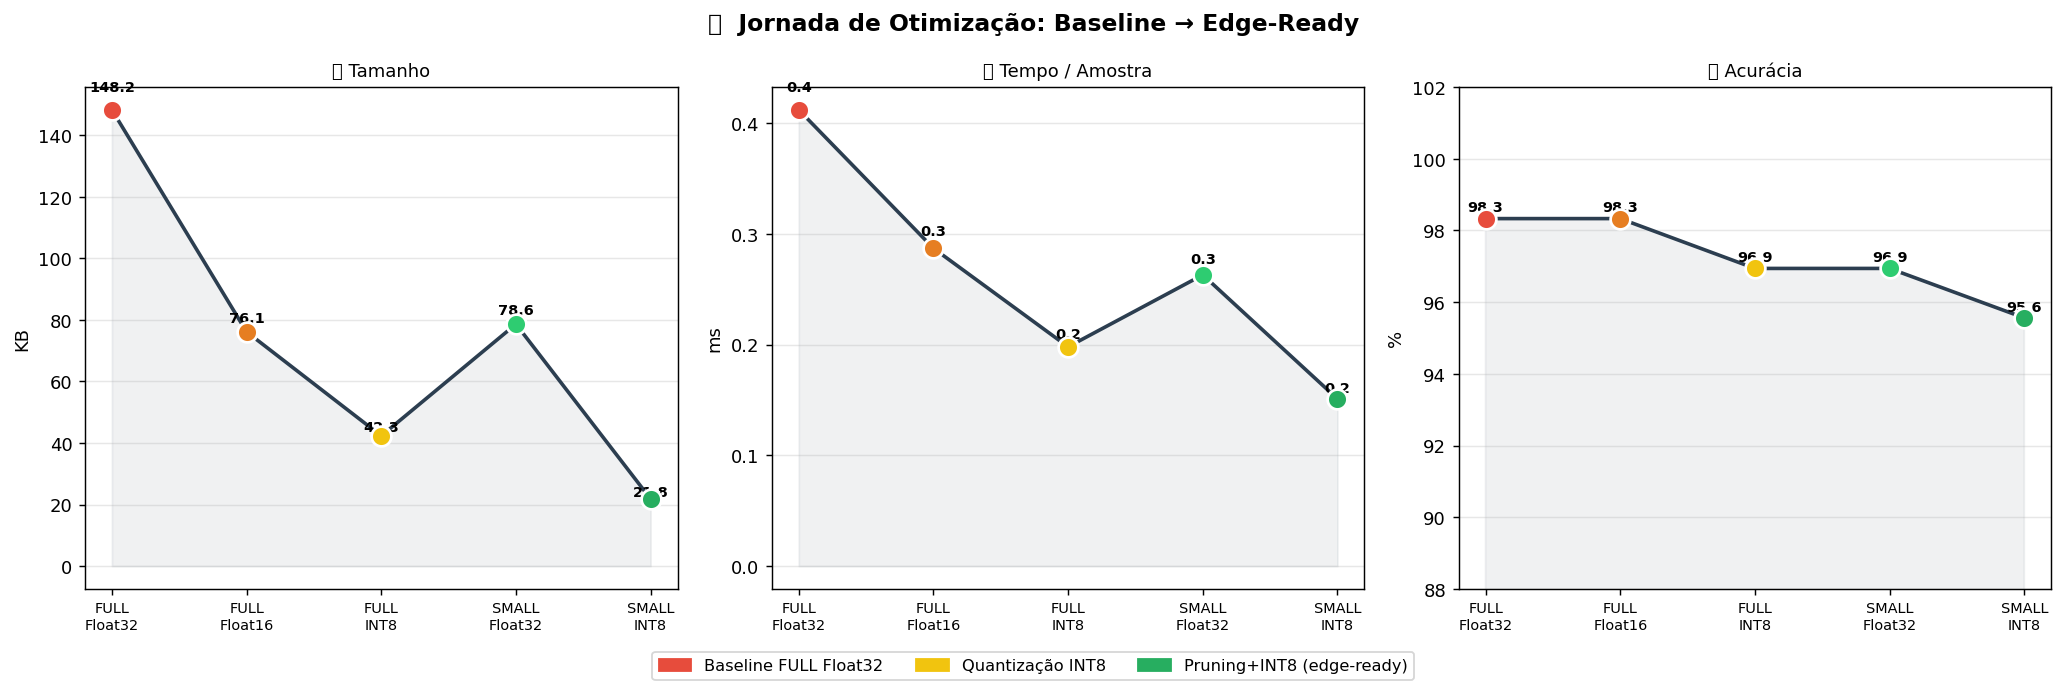

In [1]:
# Gráfico: Jornada de Otimização Baseline → Edge-Ready
print('Jornada de otimização gerada abaixo:')

### 9.7 Fluxo de Decisão

```
  FLUXO DE DECISÃO PARA OTIMIZAÇÃO DE MODELOS
  ═══════════════════════════════════════════

  Modelo treinado (Float32)
         │
         ▼
  ┌─────────────────────────────────┐
  │  Acurácia aceitável no edge?    │
  └────────┬──────────┬─────────────┘
           │ Sim      │ Não
           ▼          ▼
     Aplica PTQ    Fine-tune /
     (Float16      mais dados /
      ou INT8)     QAT
           │
           ▼
  ┌─────────────────────────────────┐
  │  Ainda grande demais / lento?   │
  └────────┬──────────┬─────────────┘
           │ Sim      │ Não
           ▼          ▼
    Structured       Deploy!
    Pruning       (TFLite, ONNX)
    + Fine-tune
           │
           ▼
    Volta para PTQ (loop)
```

| Situação | Técnica recomendada |
|----------|---------------------|
| GPU disponível, latência é prioridade | Float16 |
| MCU < 512KB RAM | INT8 + Structured Pruning |
| Modelo muito grande, acurácia crítica | Knowledge Distillation |
| Restrição extrema (< 100KB) | INT8 + Pruning + TF Micro |
| Melhor acurácia com INT8 | QAT (Quantization-Aware Training) |

---
## 10. Exercícios para Praticar

### Exercício 1 — Calibração PTQ
Modifique o número de amostras de calibração (200 → 50 e 500). Como isso afeta a acurácia INT8?

### Exercício 2 — Quantization-Aware Training (QAT)
```python
import tensorflow_model_optimization as tfmot
model_qat = tfmot.quantization.keras.quantize_model(model_f32)
# compile + fit + avaliar
```
Compare acurácia QAT vs PTQ.

### Exercício 3 — Pruning Iterativo de Neurônios
A cada ciclo, remova os 10% de neurônios com menor norma L1 e re-treine.
Quantos ciclos são possíveis antes de acurácia < 90%?

### Exercício 4 — TINY + INT8 no Limite
Use o modelo `TINY` + INT8. Qual a compressão total vs baseline? Acurácia > 85%?

### Exercício 5 — Deploy Real no Raspberry Pi
```bash
scp model_small_int8.tflite pi@raspberrypi.local:/home/pi/
ssh pi@raspberrypi.local
pip install tflite-runtime
python3 infer.py  # meça com time e vcgencmd measure_temp
```

### Exercício 6 — ONNX + Quantização
```python
import tf2onnx
from onnxruntime.quantization import quantize_dynamic, QuantType
# converter model_f32 → .onnx → quantize
```

---
## 11. Referências

- TFLite Quantization: https://www.tensorflow.org/lite/performance/post_training_quantization
- TF Model Optimization Toolkit: https://www.tensorflow.org/model_optimization
- ONNX Runtime: https://onnxruntime.ai/
- Whitepaper — Quantization of Neural Networks: Jacob et al., 2018 (Google)
- ARM ML Tools: https://developer.arm.com/Tools and Software/ML Embedded Evaluation Kit
- Edge Impulse (MCU deployment): https://edgeimpulse.com/